# Setup and Starter Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, models, callbacks
from keras.datasets import cifar10
from keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']
# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()
# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test:{x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test:(10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


# 🟢 Task 1: Data Preprocessing Experiments

## 🔴 1A. Normalization Comparison

### ⚫ Description: Comparing No Normalization, Min-Max, and Standardization.

In [56]:
from tensorflow import keras
import time
import pandas as pd
def BaselineCNN():
  model = models.Sequential([
      layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
      layers.MaxPooling2D((2, 2)),
      layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
      layers.MaxPooling2D((2, 2)),
      layers.Flatten(),
      layers.Dense(128, activation='relu'),
      layers.Dense(10, activation='softmax')
  ])
  return model

# EXP A
x_train_A = x_train.copy()
x_val_A = x_val.copy()
x_test_A = x_test.copy()

# EXP B
x_train_B = x_train / 255.0
x_val_B = x_val / 255.0
x_test_B = x_test / 255.0

# EXP C
mean = x_train.mean(axis=(0, 1, 2))
std = x_train.std(axis=(0, 1, 2))

x_train_C = (x_train - mean) / std
x_val_C = (x_val - mean) / std
x_test_C = (x_test - mean) / std

In [57]:
# Training Config
EPOCHS = 20
BATCH_SIZE = 128

# Dictionary to store different preprocessing versions of the dataset
experiments = {
    'Raw': (x_train_A, x_val_A,  x_test_A),
    'Min-Max': (x_train_B, x_val_B,  x_test_B),
    'Standardized': (x_train_C, x_val_C,  x_test_C),
}

histories = {}
# Loop over each preprocessing method
for name, (x_tr, x_v, x_te) in experiments.items():
    model = BaselineCNN()
    model.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_tr, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(x_v, y_val),
        verbose=1
    )

    # Save training history (used later for plotting curves)
    histories[name] = history
    loss, acc = model.evaluate(x_te, y_test, verbose=0)
    print(f"{name} → Test Acc: {acc*100:.2f}%  |  Loss: {loss:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.2885 - loss: 3.7490 - val_accuracy: 0.4006 - val_loss: 1.6682
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4712 - loss: 1.4786 - val_accuracy: 0.4851 - val_loss: 1.4492
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5446 - loss: 1.2774 - val_accuracy: 0.5250 - val_loss: 1.3632
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5975 - loss: 1.1436 - val_accuracy: 0.5156 - val_loss: 1.3972
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6329 - loss: 1.0488 - val_accuracy: 0.5310 - val_loss: 1.3892
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6624 - loss: 0.9630 - val_accuracy: 0.5449 - val_loss: 1.3957
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6984 - loss: 0.8700 - val_accuracy: 0.5446 - val_loss: 1.4487
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7200 - loss: 0.8013 - val_accuracy: 0

### ⚫ Table

In [58]:
results ={
    'Experiment': [],
    'Final Train Accuracy': [],
    'Final Val Accuracy': [],
    'Test Accuracy': [],
    'Initial Loss': []
}
for name, h in histories.items():
    results['Experiment'].append(name)
    results['Final Train Accuracy'].append(h.history['accuracy'][-1])
    results['Final Val Accuracy'].append(h.history['val_accuracy'][-1])
    loss, acc = model.evaluate(experiments[name][2], y_test, verbose=0)
    results['Test Accuracy'].append(acc)
    results['Initial Loss'].append(h.history['loss'][0])
dataframe = pd.DataFrame(results)
display(dataframe)

,Experiment,Final Train Accuracy,Final Val Accuracy,Test Accuracy,Initial Loss
0,Raw,0.885025,0.5425,0.4008,3.748961
1,Min-Max,0.914375,0.6638,0.2886,1.562526
2,Standardized,0.963425,0.6656,0.6665,1.388310


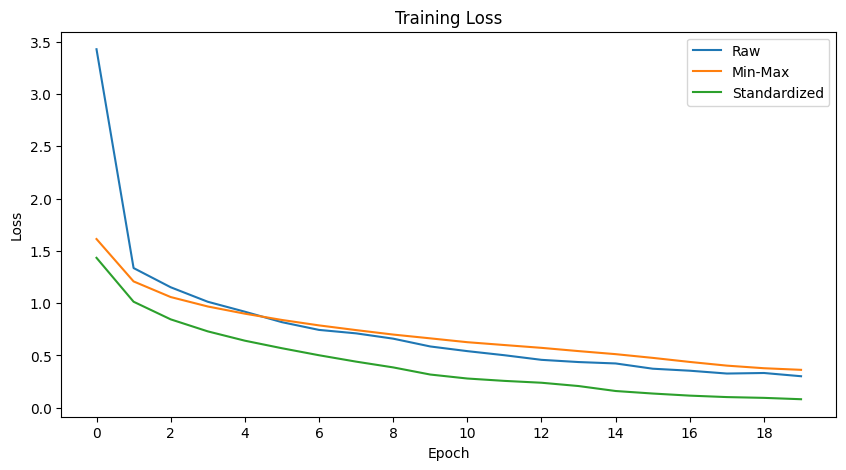

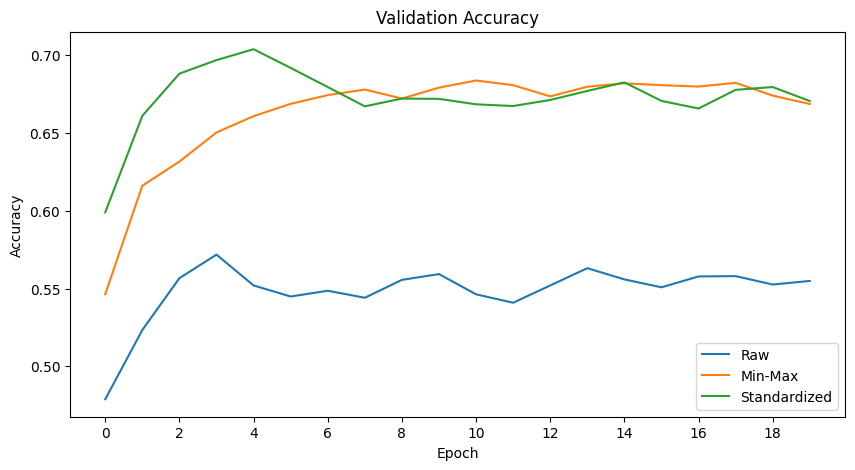

In [4]:
# Plot 1: Training Loss
plt.figure(figsize=(10, 5))
for name, h in histories.items():
    plt.plot(h.history['loss'], label=name)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.xticks(range(0, EPOCHS, 2))
plt.show()

# Plot 2: Validation Accuracy
plt.figure(figsize=(10, 5))
for name, h in histories.items():
    plt.plot(h.history['val_accuracy'], label=name)
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.xticks(range(0, EPOCHS, 2))
plt.show()

## 🔴 1B. Data Augmentation Comparison

### ⚫ Description: Using the standardized data from Exp C, train the BaselineCNN with and without data augmentation

In [5]:
# Training Config
EPOCHS = 40
BATCH_SIZE = 128

# Exp 1 : No Augmentation
model_withoutAug = BaselineCNN()
model_withoutAug.compile(optimizer=keras.optimizers.Adam(0.001),
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

history_withoutAug = model_withoutAug.fit(x_train_C, y_train,
                                         epochs=EPOCHS, batch_size=BATCH_SIZE,
                                         validation_data=(x_val_C, y_val), verbose=1)

loss_withoutAug, acc_withoutAug = model_withoutAug.evaluate(x_test_C, y_test, verbose=0)
print(f"No Augmentation → Test Acc: {acc_withoutAug*100:.2f}%  |  Loss: {loss_withoutAug:.4f}")

# Exp 2: With Augmentation
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(x_train_C)

model_withAug = BaselineCNN()
model_withAug.compile(optimizer=keras.optimizers.Adam(0.001),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

history_withAug = model_withAug.fit(datagen.flow(x_train_C, y_train, batch_size=BATCH_SIZE),
                                    epochs=EPOCHS,
                                    validation_data=(x_val_C, y_val), verbose=1)

loss_withAug, acc_withAug = model_withAug.evaluate(x_test_C, y_test, verbose=0)
print(f"With Augmentation → Test Acc: {acc_withAug*100:.2f}%  |  Loss: {loss_withAug:.4f}")

Epoch 1/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5066 - loss: 1.3957 - val_accuracy: 0.6046 - val_loss: 1.1378
Epoch 2/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6505 - loss: 1.0083 - val_accuracy: 0.6630 - val_loss: 0.9758
Epoch 3/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7054 - loss: 0.8506 - val_accuracy: 0.6825 - val_loss: 0.9123
Epoch 4/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7426 - loss: 0.7447 - val_accuracy: 0.6971 - val_loss: 0.8881
Epoch 5/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7723 - loss: 0.6614 - val_accuracy: 0.6929 - val_loss: 0.9061
Epoch 6/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7984 - loss: 0.5876 - val_accuracy: 0.6940 - val_loss: 0.9350
Epoch 7/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8237 - loss: 0.5150 - val_accuracy: 0.6805 - val_loss: 1.0339
Epoch 8/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8483 - loss: 0.4482 - val_accuracy: 0

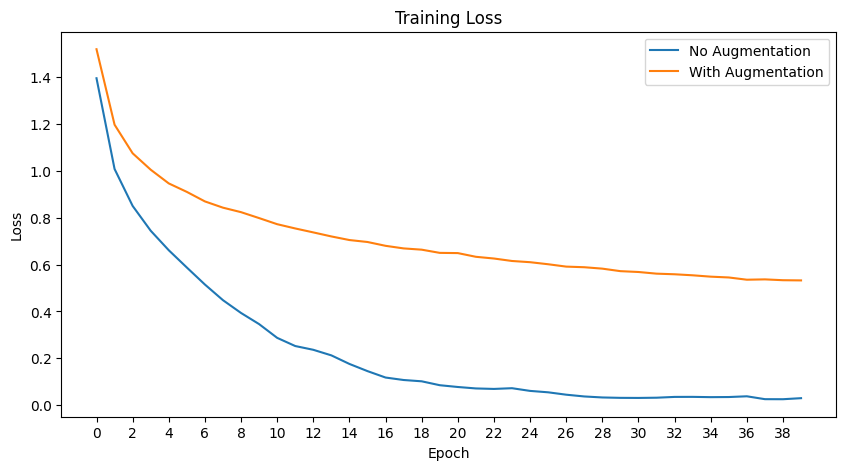

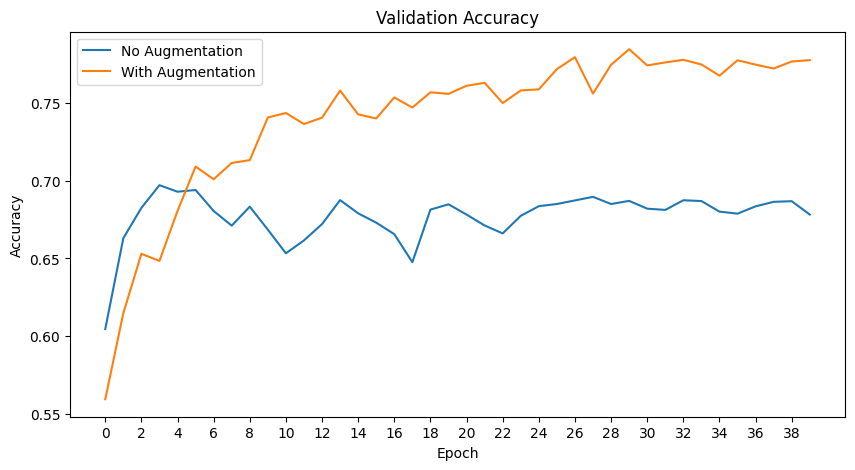

In [6]:
# Plot 1: Training Loss
plt.figure(figsize=(10, 5))
plt.plot(history_withoutAug.history['loss'], label='No Augmentation')
plt.plot(history_withAug.history['loss'], label='With Augmentation')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(0, EPOCHS, 2))
plt.legend()
plt.show()

# Plot 2: Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history_withoutAug.history['val_accuracy'], label='No Augmentation')
plt.plot(history_withAug.history['val_accuracy'], label='With Augmentation')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(range(0, EPOCHS, 2))
plt.legend()
plt.show()

# 🟢 Task 2: CNN Architecture Experiments

## ⚫ Use standardized data for ALL experiments in this task.

## 🔴 2A. Filter Count Comparison

### ⚫ Description: Testing Small, Medium, and Large filter configurations.

In [7]:
import time
import pandas as pd

# Function to build models with diffrent filter counts
def build_model_2a(f1, f2, f3, f4):
    model = models.Sequential([
        layers.Conv2D(f1, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(f2, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(f3, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(f4, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

filter_configs = {
    'Small': (8, 8, 16, 16),
    'Medium': (32, 32, 64, 64),
    'Large': (64, 64, 128, 128)
}

histories_2a = {}
results_2a = []

for name, (f1, f2, f3, f4) in filter_configs.items():
    print(f"\n=================================")
    print(f"Training Model: {name} Filter Count")
    print(f"=================================")

    model = build_model_2a(f1, f2, f3, f4)
    model.summary()

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # train model
    start_time = time.time()
    history = model.fit(
        x_train_C, y_train,
        epochs=20,
        batch_size=128,
        validation_data=(x_val_C, y_val),
        verbose=1
    )
    time_taken = time.time() - start_time

    histories_2a[name] = history

    # Evaluation
    test_loss, test_acc = model.evaluate(x_test_C, y_test, verbose=0)

    # Store metrics for table
    results_2a.append({
        'Model': name,
        'Total Params': model.count_params(),
        'Train Acc': history.history['accuracy'][-1],
        'Val Acc': history.history['val_accuracy'][-1],
        'Test Acc': test_acc,
        'Time (s)': time_taken
    })

# results Table
df_2a = pd.DataFrame(results_2a)
print(f"\n=================================")
print("Results: Filter Count Comparison")
print(f"=================================")
display(df_2a)


Training Model: Small Filter Count


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,266 (1.03 MB)

 Trainable params: 269,266 (1.03 MB)

...

 Total params: 2,360,138 (9.00 MB)

 Trainable params: 2,360,138 (9.00 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.5141 - loss: 1.3674 - val_accuracy: 0.6446 - val_loss: 1.0216
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7034 - loss: 0.8504 - val_accuracy: 0.6971 - val_loss: 0.8518
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7795 - loss: 0.6328 - val_accuracy: 0.7216 - val_loss: 0.8089
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8275 - loss: 0.4972 - val_accuracy: 0.7385 - val_loss: 0.8245
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8600 - loss: 0.3978 - val_accuracy: 0.7377 - val_loss: 0.8700
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8974 - loss: 0.2900 - val_accuracy: 0.7408 - val_loss: 0.9678
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9302 - loss: 0.1963 - val_accuracy: 0.7189 - val_loss: 1.2575
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9435 - loss: 0.1581 - val_acc

,Model,Total Params,Train Acc,Val Acc,Test Acc,Time (s)
0,Small,269266,0.945750,0.6305,0.6276,44.349493
1,Medium,1116970,0.985475,0.7132,0.7085,80.935019
2,Large,2360138,0.986025,0.7427,0.7410,148.265260


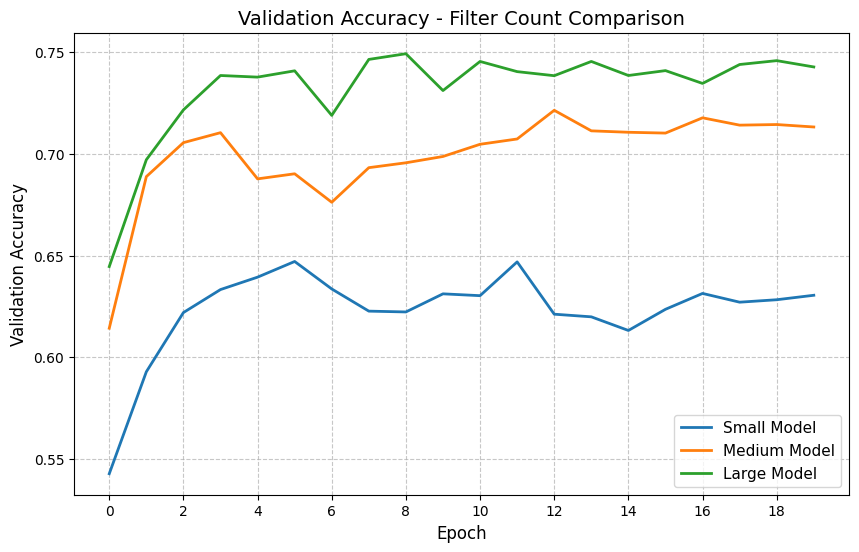

In [8]:
# Plot val accuracy curves for all 3 on one graph
plt.figure(figsize=(10, 6))
for name, h in histories_2a.items():
    plt.plot(h.history['val_accuracy'], label=f'{name} Model', lw=2)

plt.title('Validation Accuracy - Filter Count Comparison', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.xticks(range(0, 20, 2))
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 🔴 2B. Network Depth Comparison

### ⚫ Description: Comparing Shallow (4 layers), Medium (6 layers), and Deep (8 layers).

In [9]:
def build_shallow():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

def build_medium_depth():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

def build_deep():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

depth_models = {
    'Shallow': build_shallow(),
    'Medium': build_medium_depth(),
    'Deep': build_deep()
}

histories_2b = {}
results_2b = []

for name, model in depth_models.items():
    print(f"\n=================================")
    print(f"Training Model: {name} Depth")
    print(f"=================================")

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    start_time = time.time()
    history = model.fit(
        x_train_C, y_train,
        epochs=20,
        batch_size=128,
        validation_data=(x_val_C, y_val),
        verbose=1
    )
    time_taken = time.time() - start_time

    histories_2b[name] = history
    test_loss, test_acc = model.evaluate(x_test_C, y_test, verbose=0)

    results_2b.append({
        'Model': name,
        'Total Params': model.count_params(),
        'Train Acc': history.history['accuracy'][-1],
        'Val Acc': history.history['val_accuracy'][-1],
        'Test Acc': test_acc,
        'Time (s)': time_taken
    })

# Results Table
df_2b = pd.DataFrame(results_2b)
print(f"\n=================================")
print("Results Table 2B: Network Depth Comparison")
print(f"=================================")
display(df_2b)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training Model: Shallow Depth
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.4820 - loss: 1.4535 - val_accuracy: 0.5864 - val_loss: 1.1752
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6399 - loss: 1.0306 - val_accuracy: 0.6533 - val_loss: 0.9847
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7072 - loss: 0.8375 - val_accuracy: 0.6857 - val_loss: 0.8997
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7555 - loss: 0.7049 - val_accuracy: 0.6983 - val_loss: 0.8759
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7939 - loss: 0.5973 - val_accuracy: 0.6855 - val_loss: 0.9807
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8210 - loss: 0.5135 - val_accuracy: 0.6806 - val_loss: 1.0318
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8501 - loss: 0.4255 - val_accuracy: 0.6595 - val_loss: 1.1831
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.877

,Model,Total Params,Train Acc,Val Acc,Test Acc,Time (s)
0,Shallow,555754,0.978850,0.6873,0.6820,70.364771
1,Medium,58154,0.794675,0.7425,0.7451,77.465116
2,Deep,76650,0.826175,0.7190,0.7133,75.820634



Question: Does the deepest model perform best? Why or why not?
- Answer: No, the deepest model did not perfrom best (medium depth did). We belive that the deeper model may have overfitted to the training data, as the dimensionality of the feature space increased with depth, making it harder for the model to generalize well to unseen data.

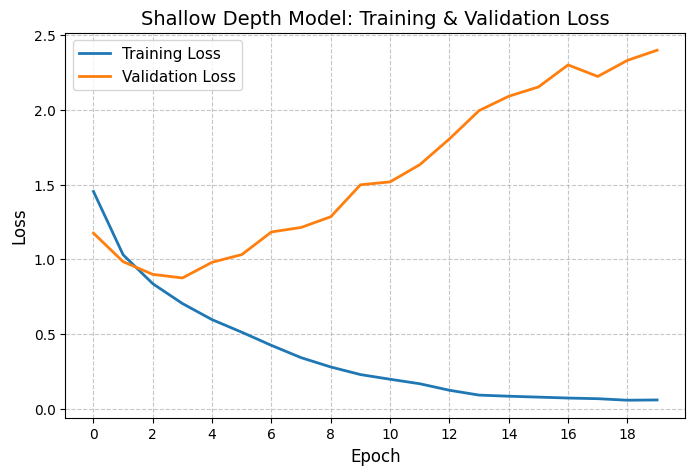

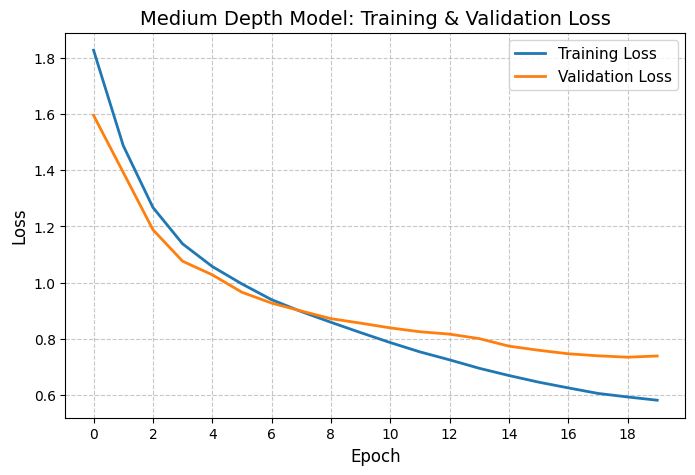

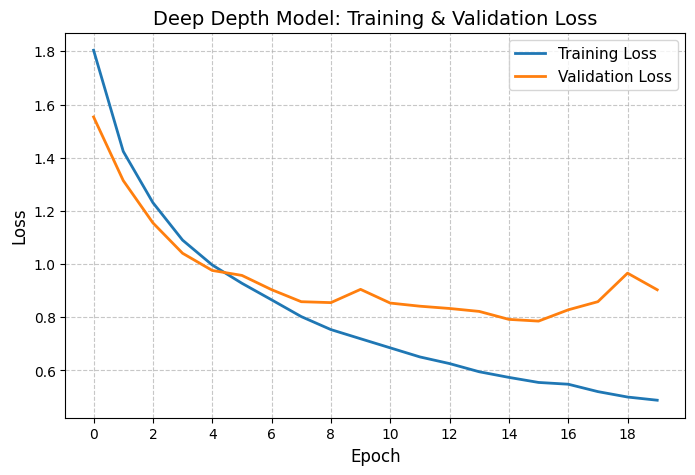

In [10]:
# Plot training loss and val loss (2 curves per plot, 3 separate plots)
for name, h in histories_2b.items():
    plt.figure(figsize=(8, 5))
    plt.plot(h.history['loss'], label='Training Loss', lw=2)
    plt.plot(h.history['val_loss'], label='Validation Loss', lw=2)

    plt.title(f'{name} Depth Model: Training & Validation Loss', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.xticks(range(0, 20, 2))
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# 🟢 Task 3: Regularization Experiments

## ⚫ Use the Medium model from Task 2A as the baseline for all experiments.

## 🔴 3A. Dropout Rate Comparison

### ⚫ Description: Comparing rates of 0.0, 0.25, and 0.5.

In [40]:
def build_D0():
    return build_model_2a(32, 32, 64, 64)  # Medium filter config from 2A

def build_D1():
    # 2A Medium + Dropout(0.25)
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.25),
        layers.Dense(10, activation='softmax')
    ], name='D1_dropout_025')
    return model

def build_D2():
    # 2A Medium + Dropout(0.5)
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.5),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.5),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ], name='D2_dropout_050')
    return model

In [42]:
# Training

model_builders = {'D0': build_D0, 'D1': build_D1, 'D2': build_D2}
histories = {}
model_dict = {}
for name, builder in model_builders.items():
    print(f"Training {name}")
    model = builder()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        x_train_C, y_train,
        epochs=30,
        batch_size=128,
        validation_data=(x_val_C, y_val),
        verbose=1
    )
    model_dict[name] = model
    histories[name] = history
    test_loss, test_acc = model.evaluate(x_test_C, y_test, verbose=0)
    print(f"{name} → Test accuracy: {test_acc:.4f}")

Training D0
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.4988 - loss: 1.4141 - val_accuracy: 0.6087 - val_loss: 1.1082
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6722 - loss: 0.9393 - val_accuracy: 0.6893 - val_loss: 0.8903
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7459 - loss: 0.7329 - val_accuracy: 0.7093 - val_loss: 0.8404
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7970 - loss: 0.5820 - val_accuracy: 0.7172 - val_loss: 0.8821
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8368 - loss: 0.4724 - val_accuracy: 0.6901 - val_loss: 1.0359
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8596 - loss: 0.4013 - val_accuracy: 0.7100 - val_loss: 0.9998
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8988 - loss: 0.2913 - val_accuracy: 0.7023 - val_loss: 1.1286
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9220 - loss: 0.22

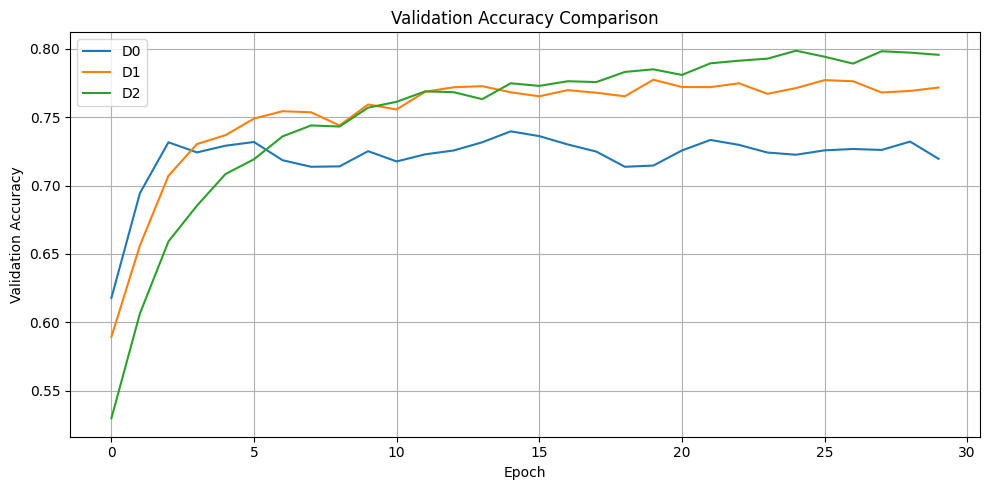

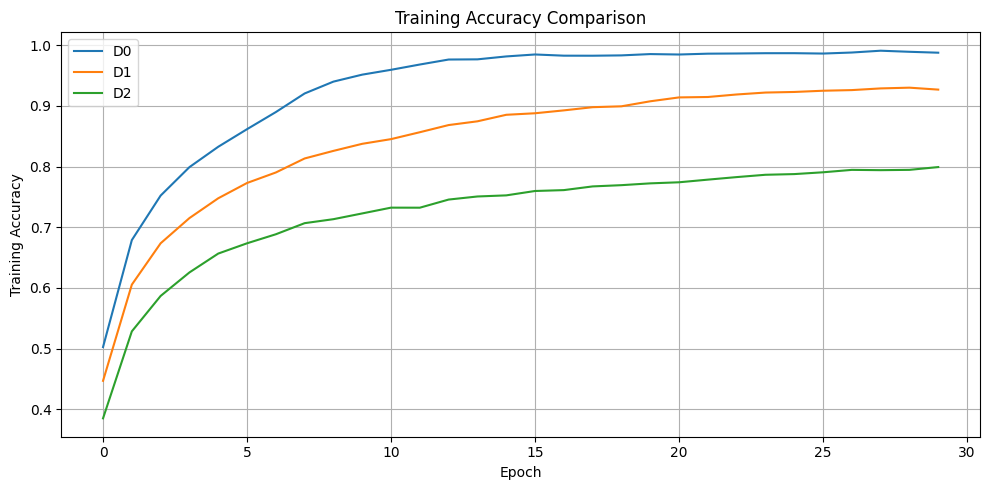

In [13]:
# Plot 1: Validation Accuracy
plt.figure(figsize=(10, 5))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Training Accuracy
plt.figure(figsize=(10, 5))
for name, history in histories.items():
    plt.plot(history.history['accuracy'], label=name)
plt.title('Training Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### ⚫ Table

In [44]:
results = {
    'Experiment': [],
    'Final Train Accuracy': [],
    'Final Val Accuracy': [],
    'Test Accuracy': [],
    'Overfit Gap': []
}
for name, h in histories.items():
    results['Experiment'].append(name)
    results['Final Train Accuracy'].append(h.history['accuracy'][-1])
    results['Final Val Accuracy'].append(h.history['val_accuracy'][-1])
    loss, acc = model_dict[name].evaluate(x_test_C, y_test, verbose=0)
    results['Test Accuracy'].append(acc)
    overfit_gap = h.history['accuracy'][-1] - h.history['val_accuracy'][-1]
    results['Overfit Gap'].append(overfit_gap)
dataframe = pd.DataFrame(results)
print("Results Table 3A: Regularization Comparison")
display(dataframe)

Results Table 3A: Regularization Comparison


,Experiment,Final Train Accuracy,Final Val Accuracy,Test Accuracy,Overfit Gap
0,D0,0.988675,0.7166,0.7122,0.272075
1,D1,0.935375,0.7792,0.7770,0.156175
2,D2,0.796625,0.7959,0.7874,0.000725


## 🔴 3B. Early Stopping Comparison

### ⚫ Description: Comparing no ES vs. patience=5 vs. patience=10.

In [14]:
es_experiments = {
    'ES0': None,  # No early stopping, 50 epochs
    'ES2': callbacks.EarlyStopping(monitor='val_loss', patience=5,  restore_best_weights=True),
    'ES3': callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
}

es_histories = {}
es_results   = {}

In [45]:
# Training
for name, callback in es_experiments.items():
    print(f"Training {name}")

    model = build_D0()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # If early stopping exists pass it as callback, otherwise empty list
    cb_list = [callback] if callback is not None else []

    start = time.time()
    history = model.fit(
        x_train_B, y_train,
        epochs=50,
        batch_size=128,
        validation_data=(x_val_B, y_val),
        callbacks=cb_list,
        verbose=1
    )
    elapsed = time.time() - start

    test_loss, test_acc = model.evaluate(x_test_B, y_test, verbose=0)
    stopped_at    = len(history.history['val_loss'])
    best_val_loss = min(history.history['val_loss'])

    es_histories[name] = history
    es_results[name]   = {
        'Stopped at Epoch': stopped_at,
        'Best Val Loss':    round(best_val_loss, 4),
        'Test Acc':         round(test_acc, 4),
        'Time (s)':         round(elapsed, 1)
    }

    print(f"{name} → Stopped at epoch {stopped_at} | "
          f"Best val loss: {best_val_loss:.4f} | "
          f"Test acc: {test_acc:.4f} | Time: {elapsed:.1f}s")

Training ES0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.4382 - loss: 1.5460 - val_accuracy: 0.5599 - val_loss: 1.2413
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6101 - loss: 1.0968 - val_accuracy: 0.6400 - val_loss: 1.0342
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6888 - loss: 0.8923 - val_accuracy: 0.6703 - val_loss: 0.9534
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7393 - loss: 0.7464 - val_accuracy: 0.6949 - val_loss: 0.8897
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7841 - loss: 0.6245 - val_accuracy: 0.7141 - val_loss: 0.8493
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8191 - loss: 0.5263 - val_accuracy: 0.7088 - val_loss: 0.8954
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8450 - loss: 0.4482 - val_accuracy: 0.7004 - val_loss: 0.9918
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8577 - loss: 0.4078 - val_acc

In [ ]:
# Plot: val loss with early stopping markers
plt.figure(figsize=(10, 5))

for name, history in es_histories.items():
    val_loss = history.history['val_loss']
    epochs   = range(1, len(val_loss) + 1)
    plt.plot(epochs, val_loss, label=name)

    # Mark stopping point with a vertical line only for ES2 and ES3
    if name != 'ES0':
        stopped_at = len(val_loss)
        plt.axvline(
            x=stopped_at,
            linestyle='--',
            label=f'{name} stopped at epoch {stopped_at}'
        )

plt.title('Validation Loss with Early Stopping Points')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### ⚫ Table

In [46]:
results_df = pd.DataFrame(es_results).T
print("\nResults Table 3B: Early Stopping Comparison")
display(results_df)


Results Table 3B: Early Stopping Comparison


,Stopped at Epoch,Best Val Loss,Test Acc,Time (s)
ES0,50.0,0.8493,0.7212,185.7
ES2,9.0,0.8467,0.7019,51.0
ES3,15.0,0.8712,0.7010,66.4


# 🟢 Task 4: Optimizer Comparison

## ⚫ Use the Medium model from Task 2A. Use standardized data.

## 🔴 4A. Same Learning Rate — 5 Optimizers.

### ⚫ Description: SGD, Momentum, AdaGrad, RMSProp, and Adam.

### ⚫ Train with all 5 optimizers at learning_rate = 0.001, 30 epochs, batch_size=128

In [16]:
import time
import pandas as pd
import tensorflow as tf

# Define the 5 optimizers with learning_rate= 0.001
optimizers_dict = {
    'SGD': tf.keras.optimizers.SGD(learning_rate=0.001),
    'Momentum': tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    'AdaGrad': tf.keras.optimizers.Adagrad(learning_rate=0.001),
    'RMSProp': tf.keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': tf.keras.optimizers.Adam(learning_rate=0.001)
}

histories_4a = {}
results_4a = []

for name, opt in optimizers_dict.items():
    print(f"\n=================================")
    print(f"Training Model: {name} Optimizer")
    print(f"=================================")

    # Build Medium model from Task 2A
    model = build_model_2a(32, 32, 64, 64)

    model.compile(optimizer=opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # train model
    start_time = time.time()
    history = model.fit(
        x_train_C, y_train,
        epochs=30,
        batch_size=128,
        validation_data=(x_val_C, y_val),
        verbose=1
    )
    time_taken = time.time() - start_time

    histories_4a[name] = history

    # Evaluation
    test_loss, test_acc = model.evaluate(x_test_C, y_test, verbose=0)

    # Store metris for table
    results_4a.append({
        'Optimizer': name,
        'Train Acc': history.history['accuracy'][-1],
        'Val Acc': history.history['val_accuracy'][-1],
        'Test Acc': test_acc,
        'Time (s)': time_taken
    })

# Results Table
df_4a = pd.DataFrame(results_4a)
print(f"\n=================================")
print("Results: Optimizer Comparison")
print(f"=================================")
display(df_4a)


Training Model: SGD Optimizer
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.1297 - loss: 2.2948 - val_accuracy: 0.1665 - val_loss: 2.2806
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1782 - loss: 2.2685 - val_accuracy: 0.2085 - val_loss: 2.2513
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.2279 - loss: 2.2292 - val_accuracy: 0.2580 - val_loss: 2.1949
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2652 - loss: 2.1502 - val_accuracy: 0.2884 - val_loss: 2.0924
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2954 - loss: 2.0414 - val_accuracy: 0.3150 - val_loss: 1.9871
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3243 - loss: 1.9439 - val_accuracy: 0.3324 - val_loss: 1.9049
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3461 - loss: 1.8701 - val_accuracy: 0.3492 - val_loss: 1.8475
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0

,Optimizer,Train Acc,Val Acc,Test Acc,Time (s)
0,SGD,0.535200,0.5220,0.5242,109.808723
1,Momentum,0.889350,0.6904,0.6830,112.886685
2,AdaGrad,0.610375,0.5667,0.5714,115.346277
3,RMSProp,0.990225,0.7180,0.7148,115.099665
4,Adam,0.988825,0.7221,0.7129,115.319048


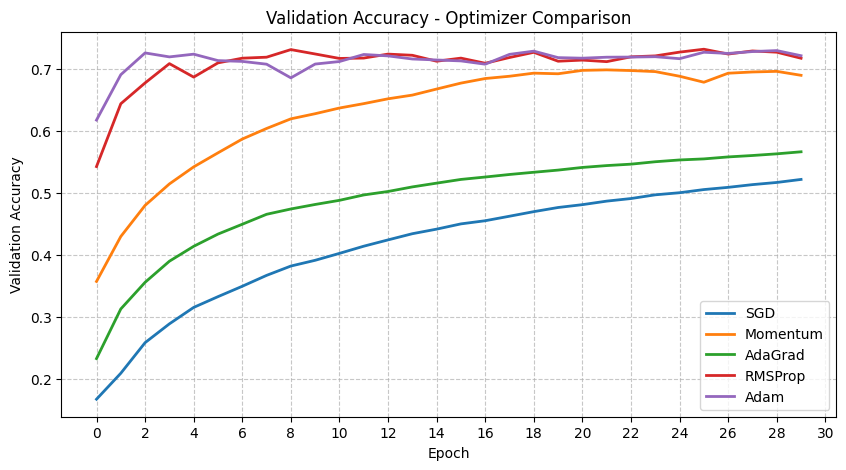

In [17]:
# Plot Validation Accuracy for all 5 optimizers
plt.figure(figsize=(10, 5))
for name, h in histories_4a.items():
    plt.plot(h.history['val_accuracy'], label=name, lw=2)

plt.title('Validation Accuracy - Optimizer Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.xticks(range(0, 32, 2))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 🔴 4B. Learning Rate Sensitivity — Adam

### ⚫ Description: Testing LR values: 0.0001, 0.001, 0.01. (30 epochs, batch_size=128)

In [18]:
lr_values = [0.0001, 0.001, 0.01]
histories_4b = {}
results_4b = []

for lr in lr_values:
    name = f"Adam (LR={lr})"
    print(f"\n=================================")
    print(f"Training Model: {name}")
    print(f"=================================")

    # Build Meduim model from Task 2A
    model = build_model_2a(32, 32, 64, 64)

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Train model
    start_time = time.time()
    history = model.fit(
        x_train_C, y_train,
        epochs=30,
        batch_size=128,
        validation_data=(x_val_C, y_val),
        verbose=1
    )
    time_taken = time.time() - start_time

    histories_4b[name] = history

    # Evaluation
    test_loss, test_acc = model.evaluate(x_test_C, y_test, verbose=0)

    # Store metrics for table
    results_4b.append({
        'Learning Rate': lr,
        'Train Acc': history.history['accuracy'][-1],
        'Val Acc': history.history['val_accuracy'][-1],
        'Test Acc': test_acc,
        'Time (s)': time_taken
    })

# Results Table
df_4b = pd.DataFrame(results_4b)
print(f"\n=================================")
print("Results: Adam Learning Rate Sensitivity")
print(f"=================================")
display(df_4b)


Training Model: Adam (LR=0.0001)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.3824 - loss: 1.7329 - val_accuracy: 0.4801 - val_loss: 1.4735
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5199 - loss: 1.3581 - val_accuracy: 0.5386 - val_loss: 1.3127
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5670 - loss: 1.2280 - val_accuracy: 0.5745 - val_loss: 1.2256
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5999 - loss: 1.1400 - val_accuracy: 0.6009 - val_loss: 1.1549
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6306 - loss: 1.0649 - val_accuracy: 0.6175 - val_loss: 1.1034
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6559 - loss: 1.0003 - val_accuracy: 0.6367 - val_loss: 1.0616
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6770 - loss: 0.9428 - val_accuracy: 0.6461 - val_loss: 1.0313
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6938 - loss: 0.8921 - val_acc

,Learning Rate,Train Acc,Val Acc,Test Acc,Time (s)
0,0.0001,0.928050,0.6574,0.6581,122.036619
1,0.0010,0.991425,0.7282,0.7218,113.159363
2,0.0100,0.743875,0.4799,0.4865,111.081601


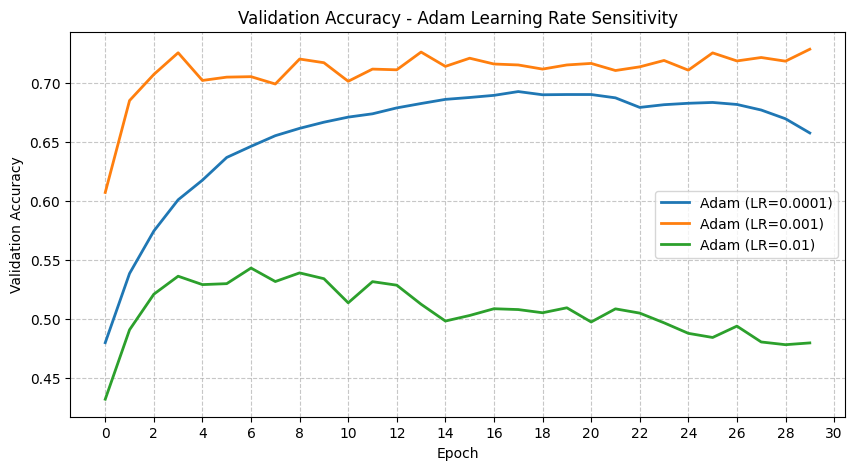

In [19]:
# Plot Validation Accuracy for the 3 learning rates
plt.figure(figsize=(10, 5))
for name, h in histories_4b.items():
    plt.plot(h.history['val_accuracy'], label=name, lw=2)

plt.title('Validation Accuracy - Adam Learning Rate Sensitivity')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.xticks(range(0, 32, 2))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Question: Which optimizer converges fastest (reaches val_acc > 0.65 first)?
- Answer: LR= 0.001 was the fastest to converge as it exceeded val_acc=65 in the second epoch, while LR= 0.0001 converged in the 8th epoch, and LR=0.01 didn't even reach val_acc=0.65.

Question: Which learning rate is too slow? Which is unstable? Which is the best?
- Answer:
    - LR = 0.0001 is too slow (very small updates)
    - LR = 0.01 is unstable (Updates are too large)
    - LR = 0.001 is the best (Balanced updates, Converges fast)

# 🟢 Task 5: Performance Evaluation

## 🔴 5A. Best Model Selection

In [20]:
# train using min-max normalization, with data augmentation, large (64,64,128,128), medium depth (6 conv layers), dropout (0.5), early stopping (patience 7,restore_best_weights=True),adam optimizer with lr=0.001, batch size 128, for 50 epochs
best_model = models.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(x_train_B)
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
history_best = best_model.fit(datagen.flow(x_train_B, y_train, batch_size=128),epochs=50,validation_data=(x_val_B, y_val),callbacks=[early_stop],verbose=1)
test_loss, test_acc = best_model.evaluate(x_test_B, y_test, verbose=0)
print("we chose the min-max normalization + data augmentation + large filter count + medium depth + dropout + early stopping configuration as our best model based on the validation accuracy and training curves.")

print(f"Best Model → Test Acc: {test_acc*100:.2f}% |  Loss: {test_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 153ms/step - accuracy: 0.2353 - loss: 1.9690 - val_accuracy: 0.3716 - val_loss: 1.6306
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.4016 - loss: 1.5923 - val_accuracy: 0.4871 - val_loss: 1.3799
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 94ms/step - accuracy: 0.4946 - loss: 1.3681 - val_accuracy: 0.5511 - val_loss: 1.2061
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 90ms/step - accuracy: 0.5521 - loss: 1.2326 - val_accuracy: 0.6214 - val_loss: 1.0212
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.5968 - loss: 1.1150 - val_accuracy: 0.6548 - val_loss: 0.9518
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - accuracy: 0.6315 - loss: 1.0342 - val_accuracy: 0.6859 - val_loss: 0.8662
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.6603 - loss: 0.9585 - val_accuracy: 0.7024 - val_loss: 0.8228
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 91ms/step - accuracy: 0.6793 - loss: 0.8996 -

## 🔴 5B. Error Analysis

### ⚫ Display the confusion matrix as a heatmap (label axes with class names):

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


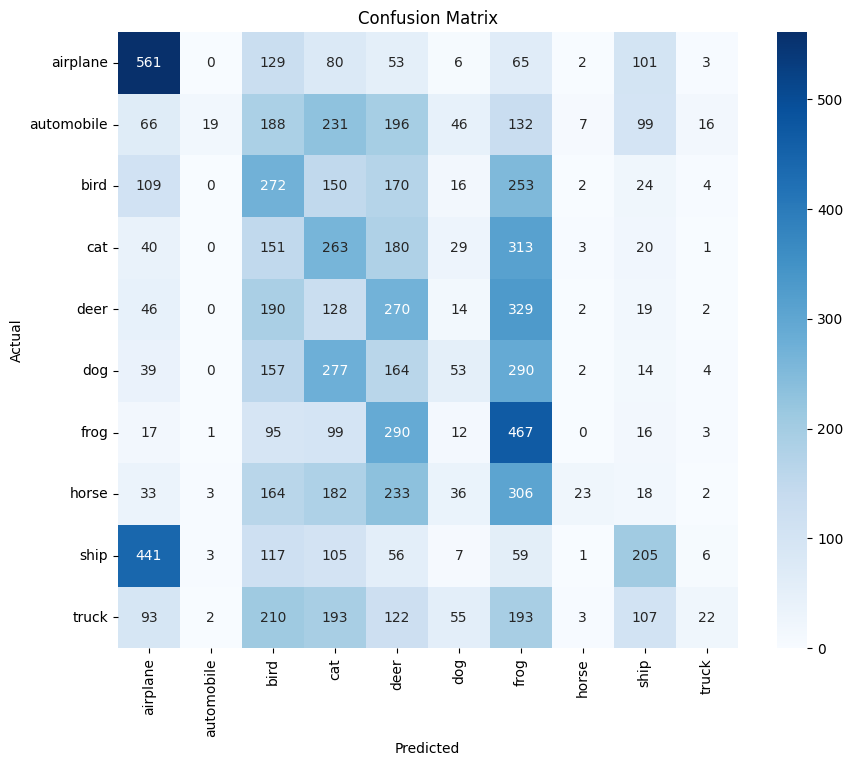

              precision    recall  f1-score   support

    airplane       0.39      0.56      0.46      1000
  automobile       0.68      0.02      0.04      1000
        bird       0.16      0.27      0.20      1000
         cat       0.15      0.26      0.19      1000
        deer       0.16      0.27      0.20      1000
         dog       0.19      0.05      0.08      1000
        frog       0.19      0.47      0.27      1000
       horse       0.51      0.02      0.04      1000
        ship       0.33      0.20      0.25      1000
       truck       0.35      0.02      0.04      1000

    accuracy                           0.22     10000
   macro avg       0.31      0.22      0.18     10000
weighted avg       0.31      0.22      0.18     10000



In [33]:
y_pred = np.argmax(model.predict(x_test_B), axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

### ⚫ Find the 3 worst-performing classes (lowest recall).

In [34]:
report = classification_report(y_test, y_pred, target_names=CLASS_NAMES, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df = report_df.loc[CLASS_NAMES]
lowest_3 = report_df.sort_values(by='recall').head(3)
print("The classes with the lowest recall are:")
for cls, row in lowest_3.iterrows():
    print(f"{cls}: {row['recall']:.3f}")

The classes with the lowest recall are:
automobile: 0.019
truck: 0.022
horse: 0.023


###  ⚫ For each of those 3 classes, display 5 misclassified images with their true label and predicted label.

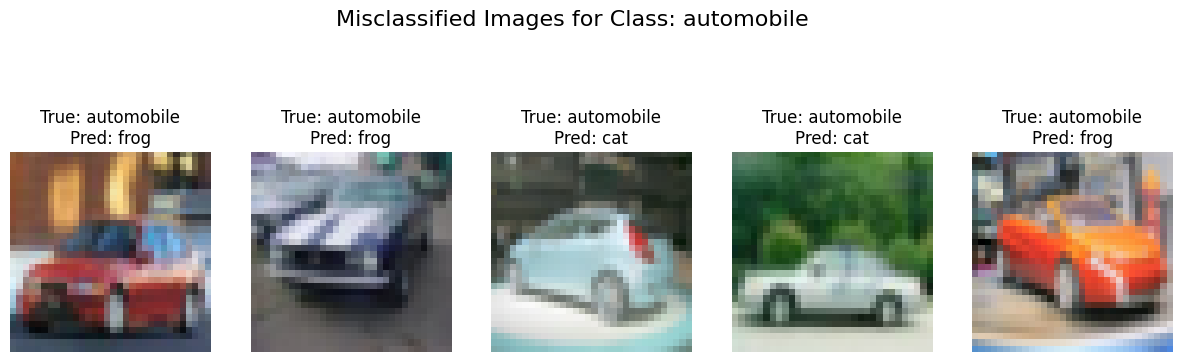

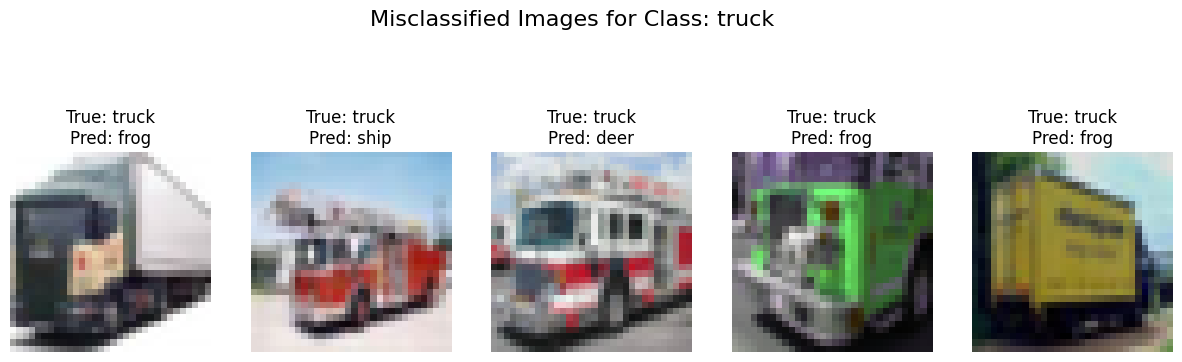

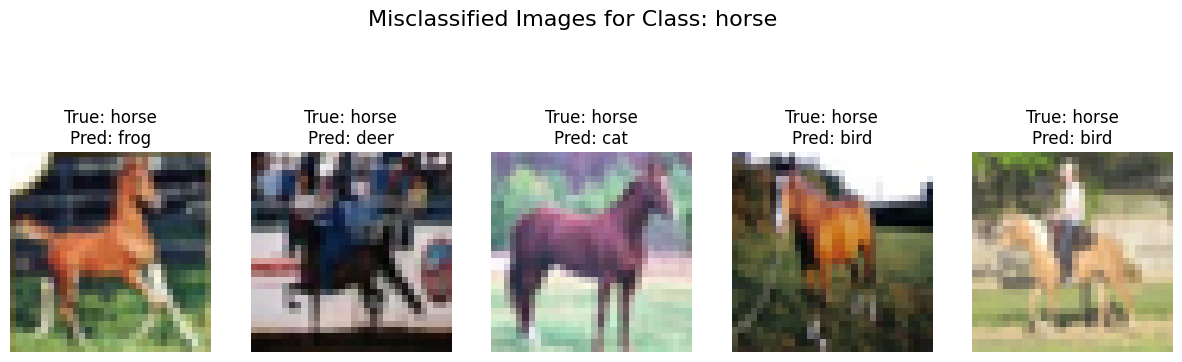

In [38]:
lowest_recall_classes = lowest_3.index.tolist()
misclassified_indices = np.where(y_test.flatten() != y_pred)[0]
for cls in lowest_recall_classes:
    cls_index = CLASS_NAMES.index(cls)
    cls_misclassified = misclassified_indices[y_test.flatten()[misclassified_indices] == cls_index]
    selected_indices = np.random.choice(cls_misclassified, size=5, replace=False)

    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(selected_indices):
        plt.subplot(1, 5, i + 1)
        plt.imshow(x_test_B[idx])
        plt.title(f"True: {CLASS_NAMES[y_test[idx][0]]}\nPred: {CLASS_NAMES[y_pred[idx]]}")
        plt.axis('off')
    plt.suptitle(f'Misclassified Images for Class: {cls}', fontsize=16)
    plt.show()


### ⚫ Find the top 3 most confused class pairs (e.g., cat↔dog). Display 4 examples from each confusion direction.


Confused Pair: "deer" with "frog" (Total: 619)

Actual: deer | Predicted: frog


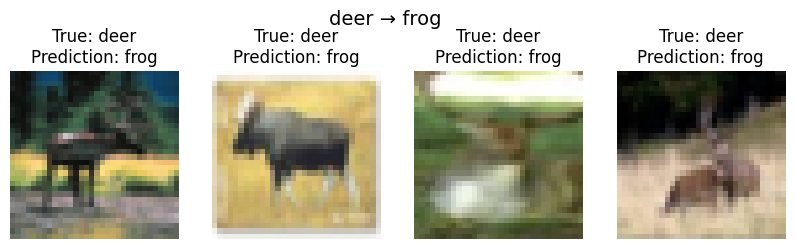


Actual: frog | Predicted: deer


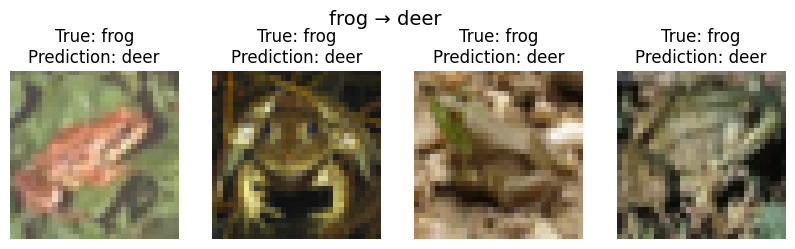


Confused Pair: "airplane" with "ship" (Total: 542)

Actual: airplane | Predicted: ship


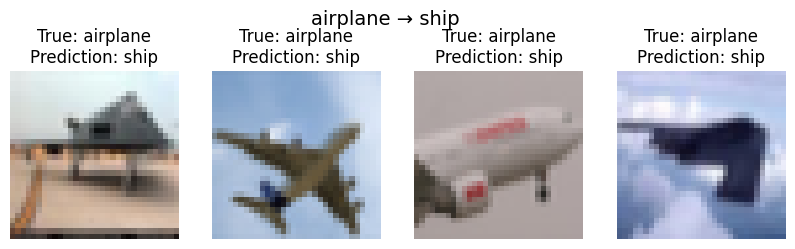


Actual: ship | Predicted: airplane


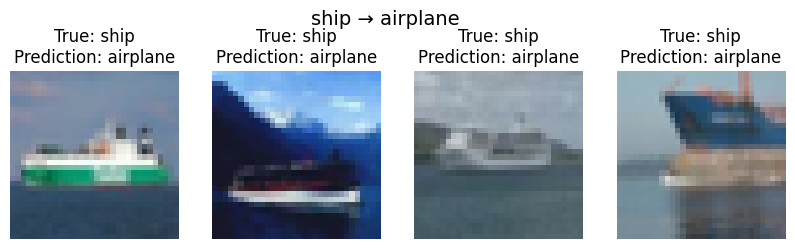


Confused Pair: "cat" with "frog" (Total: 412)

Actual: cat | Predicted: frog


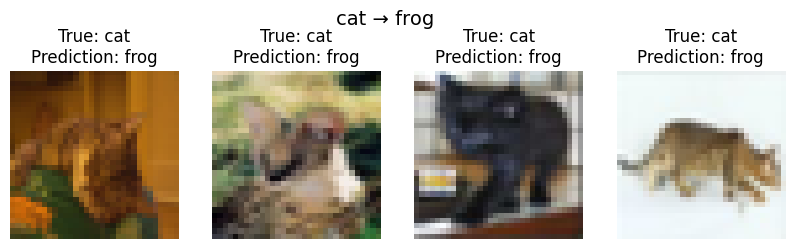


Actual: frog | Predicted: cat


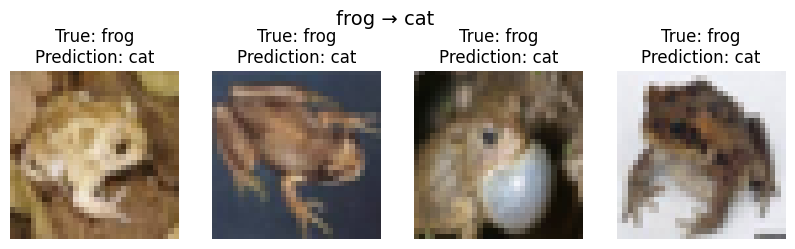

In [36]:
cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)

# here we remove the diagonal to ignore correct predictions and focus only on misclassifications
np.fill_diagonal(cm_df.values, 0)

# finding pairwise confusion (from a to b and b to a), then summing them up to get total confusion for the pair
pairs = []
for i in range(len(CLASS_NAMES)):
    for j in range(i + 1, len(CLASS_NAMES)):
        cls1 = CLASS_NAMES[i]
        cls2 = CLASS_NAMES[j]
        total_confusion = cm_df.loc[cls1, cls2] + cm_df.loc[cls2, cls1]
        pairs.append((cls1, cls2, total_confusion))

#top 3 and sort based on total_confusions
top_pairs = sorted(pairs, key=lambda x: x[2], reverse=True)[:3]

for cls1, cls2, total in top_pairs:
    print(f"\nConfused Pair: \"{cls1}\" with \"{cls2}\" (Total: {total})")

    for true_cls, pred_cls in [(cls1, cls2), (cls2, cls1)]:
        print(f"\nActual: {true_cls} | Predicted: {pred_cls}")
        true_idx = CLASS_NAMES.index(true_cls)
        pred_idx = CLASS_NAMES.index(pred_cls)
        confusion_indices = np.where((y_test.flatten() == true_idx) & (y_pred == pred_idx))[0]
        k = min(4, len(confusion_indices))
        selected_indices = np.random.choice(confusion_indices, size=k, replace=False)

        plt.figure(figsize=(10, 3))
        for i, idx in enumerate(selected_indices):
            plt.subplot(1, k, i + 1)
            plt.imshow(x_test_B[idx])
            plt.title(f"True: {true_cls}\nPrediction: {pred_cls}")
            plt.axis('off')

        plt.suptitle(f'{true_cls} → {pred_cls}', fontsize=14)
        plt.show()

#### we belive that some of classes were hard to be distinguised because:

1. they have similar features (e.g., cat and dog).
2. low image quality. (32 x 32 resolution).
3. mixed colors in background that makes it difficult for the model to learn distinctive features.
 3. class imbalance.
 4. insufficient training samples for certain classes.

# 🟢 Task 6: Transfer Learning

## 🔴 6A. Feature Extraction vs Fine-Tuning vs From Scratch

### ⚫ Step 1 — Resize CIFAR-10 for VGG16:

In [47]:
x_train_resized = tf.image.resize(x_train_C, (48, 48)).numpy()
x_val_resized = tf.image.resize(x_val_C, (48, 48)).numpy()
x_test_resized = tf.image.resize(x_test_C, (48, 48)).numpy()

### ⚫ Model 1: From Scratch

- Build the Medium CNN from Task 2A with input_shape=(48, 48, 3). Train 20 epochs, Adam(lr=0.001),  batch_size=128.

In [48]:
# Medium CNN Model with 48x48 input
model_1 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(48, 48, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])
start_time = time.time()
model_1.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),metrics=['accuracy'], loss='sparse_categorical_crossentropy')
history_1 = model_1.fit(x_train_resized, y_train, epochs=20, batch_size=128, validation_data=(x_val_resized, y_val), verbose=1)
time_taken_1 = time.time() - start_time
test_loss_1, test_acc_1 = model_1.evaluate(x_test_resized, y_test, verbose=0)
print(f"48x48 Input ---> Test Acc: {test_acc_1*100:.2f}%  |  Loss: {test_loss_1:.4f} | Time: {time_taken_1:.2f}s")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.4934 - loss: 1.4191 - val_accuracy: 0.6176 - val_loss: 1.1047
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6690 - loss: 0.9488 - val_accuracy: 0.6762 - val_loss: 0.9503
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7406 - loss: 0.7480 - val_accuracy: 0.6961 - val_loss: 0.9037
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7986 - loss: 0.5792 - val_accuracy: 0.6916 - val_loss: 0.9763
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8415 - loss: 0.4547 - val_accuracy: 0.6779 - val_loss: 1.1050
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8719 - loss: 0.3659 - val_accuracy: 0.6861 - val_loss: 1.1965
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9080 - loss: 0.2628 - val_accuracy: 0.6762 - val_loss: 1.4021
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9353 - loss: 0.1825 - val_acc

### ⚫ Model 2 — Feature Extraction (Frozen VGG16)

- Load a pre-trained VGG16 model (trained on ImageNet) without the top classification layers.

- Freeze ALL VGG16 layers so their weights do not update during training.

- Add your own classification head on top.

In [49]:
# loading VGG16 with imagenet weights, excluding top layers
from keras.applications import VGG16
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(48, 48, 3))
vgg_base.trainable = False
model_2 = models.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_2.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

start_time = time.time()
history_2 = model_2.fit(x_train_resized, y_train, epochs=20, batch_size=128, validation_data=(x_val_resized, y_val), verbose=1)
time_taken_2 = time.time() - start_time

test_loss_2, test_acc_2 = model_2.evaluate(x_test_resized, y_test, verbose=0)
print(f"VGG16 Transfer Learning ---> Test Acc: {test_acc_2*100:.2f}%  |  Loss: {test_loss_2:.4f} | Time: {time_taken_2:.2f}s")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 77ms/step - accuracy: 0.5346 - loss: 1.3313 - val_accuracy: 0.6474 - val_loss: 1.0291
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.6315 - loss: 1.0578 - val_accuracy: 0.6686 - val_loss: 0.9631
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.6572 - loss: 0.9884 - val_accuracy: 0.6769 - val_loss: 0.9360
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.6734 - loss: 0.9464 - val_accuracy: 0.6815 - val_loss: 0.9163
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.6838 - loss: 0.9095 - val_accuracy: 0.6862 - val_loss: 0.9031
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.6966 - loss: 0.8762 - val_accuracy: 0.6905 - val_loss: 0.8933
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - accuracy: 0.7021 - loss: 0.8552 - val_accuracy: 0.6917 - val_loss: 0.8878
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━

### ⚫ Model 3 — Fine-Tuning (Partial Unfreeze)

- Load a pre-trained VGG16 model (same as Model 2).

- Freeze all layers EXCEPT the last 4 layers — these will be re-trained on CIFAR-10.

- Add the same classification head (Flatten → Dense(256) → Dropout → Dense(10)).

- Use a LOWER learning rate (1e-5) to avoid destroying the pre-trained weights.

In [50]:
vgg_base.trainable = True
for layer in vgg_base.layers[:-4]:
    layer.trainable = False
model_3 = models.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
model_3.compile(optimizer=keras.optimizers.Adam(learning_rate=0.00001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
start_time = time.time()
history_3 = model_3.fit(x_train_resized, y_train, epochs=20, batch_size=128, validation_data=(x_val_resized, y_val), verbose=1)
time_taken_3 = time.time() - start_time
test_loss_3, test_acc_3 = model_3.evaluate(x_test_resized, y_test, verbose=0)
print(f"VGG16 Fine-tuning ---> Test Acc: {test_acc_3*100:.2f}%  |  Loss: {test_loss_3:.4f} | Time: {time_taken_3:.2f}s")

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 85ms/step - accuracy: 0.4366 - loss: 1.6395 - val_accuracy: 0.6770 - val_loss: 0.9744
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.6626 - loss: 1.0026 - val_accuracy: 0.7362 - val_loss: 0.7814
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.7172 - loss: 0.8432 - val_accuracy: 0.7585 - val_loss: 0.7046
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.7504 - loss: 0.7451 - val_accuracy: 0.7736 - val_loss: 0.6599
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.7731 - loss: 0.6732 - val_accuracy: 0.7848 - val_loss: 0.6246
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.7901 - loss: 0.6237 - val_accuracy: 0.7934 - val_loss: 0.5997
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.8057 - loss: 0.5753 - val_accuracy: 0.7970 - val_loss: 0.5800
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.8211 - loss: 0.5320 - 

### ⚫ Model 4 — Fine-Tuning (Higher Learning Rate)

- Same architecture and frozen layers as Model 3 (unfreeze last 4 VGG16 layers), but use a higher learning  rate (lr=0.001) instead of 1e-5.

In [51]:
model_4 = models.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
model_4.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
start_time = time.time()
history_4 = model_4.fit(x_train_resized, y_train, epochs=20, batch_size=128, validation_data=(x_val_resized, y_val), verbose=1)
time_taken_4 = time.time() - start_time
test_loss_4, test_acc_4 = model_4.evaluate(x_test_resized, y_test, verbose=0)
print(f"VGG16 Fine-tuning (LR=0.001) ---> Test Acc: {test_acc_4*100:.2f}%  |  Loss: {test_loss_4:.4f} | Time: {time_taken_4:.2f}s")

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 80ms/step - accuracy: 0.0994 - loss: 2.3234 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.0995 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.0988 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.0975 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.1003 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step - accuracy: 0.0987 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.0988 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.0988 - loss: 2.3027 - 

### ⚫Plotting

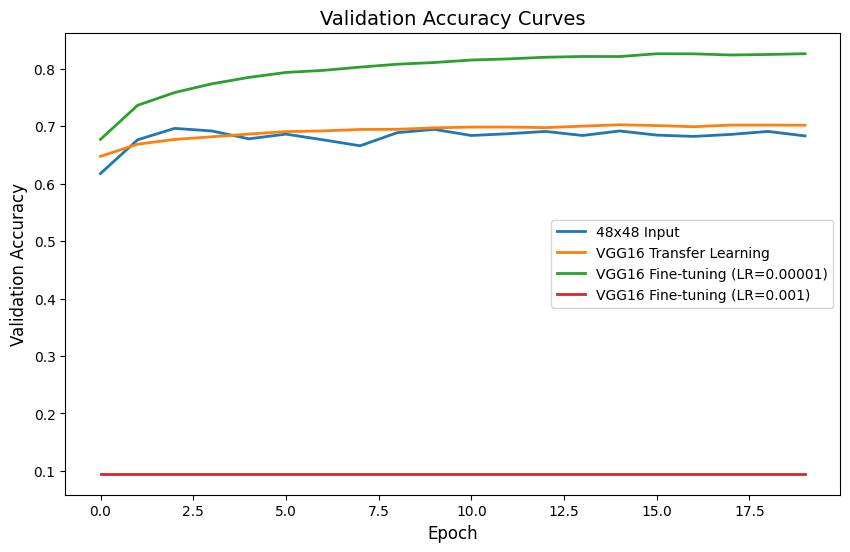

In [52]:
#plotting val accuracy curves for all 4 models on one graph
plt.figure(figsize=(10, 6))
plt.plot(history_1.history['val_accuracy'], label='48x48 Input', lw=2)
plt.plot(history_2.history['val_accuracy'], label='VGG16 Transfer Learning', lw=2)
plt.plot(history_3.history['val_accuracy'], label='VGG16 Fine-tuning (LR=0.00001)', lw=2)
plt.plot(history_4.history['val_accuracy'], label='VGG16 Fine-tuning (LR=0.001)', lw=2)
plt.title('Validation Accuracy Curves', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.legend()
plt.show()

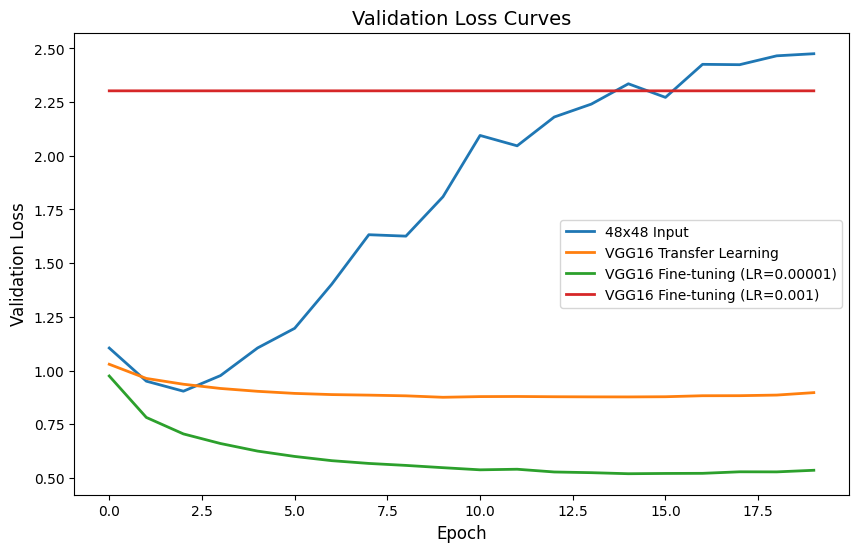

In [53]:
# plotting val loss curves for all 4 models on one graph
plt.figure(figsize=(10, 6))
plt.plot(history_1.history['val_loss'], label='48x48 Input', lw=2)
plt.plot(history_2.history['val_loss'], label='VGG16 Transfer Learning', lw=2)
plt.plot(history_3.history['val_loss'], label='VGG16 Fine-tuning (LR=0.00001)', lw=2)
plt.plot(history_4.history['val_loss'], label='VGG16 Fine-tuning (LR=0.001)', lw=2)
plt.title('Validation Loss Curves', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Loss', fontsize=12)
plt.legend()
plt.show()

### ⚫ Table

In [54]:
final_results = {
    'Model': ['Medium (48x48 Input)', 'VGG16 Transfer Learning', 'VGG16 Fine-tuning (LR=0.00001)', 'VGG16 Fine-tuning (LR=0.001)'],
    'Trainable Params': [model_1.count_params(), model_2.count_params(), model_3.count_params(), model_4.count_params()],
    'Non-Trainable Params': [0, vgg_base.count_params(), vgg_base.count_params() - sum([layer.count_params() for layer in vgg_base.layers[-4:]]), vgg_base.count_params() - sum([layer.count_params() for layer in vgg_base.layers[-4:]])],
    'Test Accuracy': [test_acc_1, test_acc_2, test_acc_3, test_acc_4],
    'Time (s)': [time_taken_1, time_taken_2, time_taken_3, time_taken_4]
}
final_df = pd.DataFrame(final_results)
print("Final Results Table: Transfer Learning Comparison")
display(final_df)

Final Results Table: Transfer Learning Comparison


,Model,Trainable Params,Non-Trainable Params,Test Accuracy,Time (s)
0,Medium (48x48 Input),2427690,0,0.6732,155.468047
1,VGG16 Transfer Learning,14848586,14714688,0.6940,365.151716
2,VGG16 Fine-tuning (LR=0.00001),14848586,7635264,0.8245,465.772122
3,VGG16 Fine-tuning (LR=0.001),14848586,7635264,0.1000,418.471902


Question: Why does Model 4 (lr=0.001) perform differently from Model 3 (lr=1e-5)?
- Answer: Model 4 with a learning rate of 0.001 performs worse than Model 3 with a learning rate of 1e-5 because the higher learning rate likely caused the weights to update too aggressively during fine-tuning, leading to divergence from the optimal weights learned during transfer learning.

Question: Does transfer learning outperform training from scratch on CIFAR-10? Why or why not?
- Answer: No, actually the best model from task 5 came up with test acc around 84% while the transfer model is around 82%, maybe because:
    1. the VGG16 architecture is quite large and may not be the best fit for CIFAR-10's smaller images.
    2. limited dataset size.
    3. our model trained from scratch may have been better able to learn features specific to CIFAR-10, leading to higher accuracy.